In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Классификация

In [2]:
df = pd.read_csv("Data/WineQT.csv")

## Датасет Wine Quality

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Использование дерева


In [5]:
df = df.drop("Id", axis=1)

In [6]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [7]:
df["quality"] -= 3

In [8]:
df["quality"].unique()

array([2, 3, 4, 1, 5, 0])

In [9]:
from tree import DecisionTreeClassifier

In [10]:
model = DecisionTreeClassifier(max_depth=30)

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [12]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

## Оценка полученной модели

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

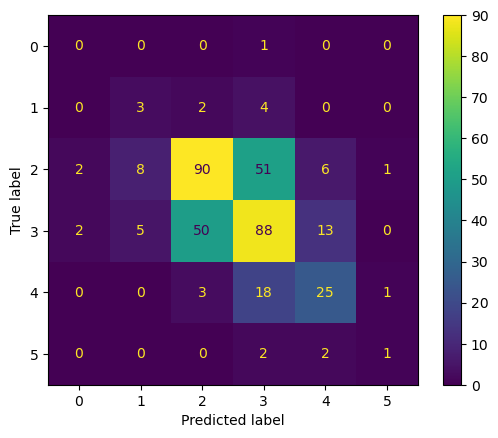

In [14]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [15]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.19      0.33      0.24         9
           2       0.62      0.57      0.59       158
           3       0.54      0.56      0.55       158
           4       0.54      0.53      0.54        47
           5       0.33      0.20      0.25         5

    accuracy                           0.55       378
   macro avg       0.37      0.37      0.36       378
weighted avg       0.56      0.55      0.55       378



## Сравнение с sklearn

In [16]:
from sklearn.tree import DecisionTreeClassifier as DT

In [17]:
model_s = DT(max_depth=30)

In [18]:
model_s.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

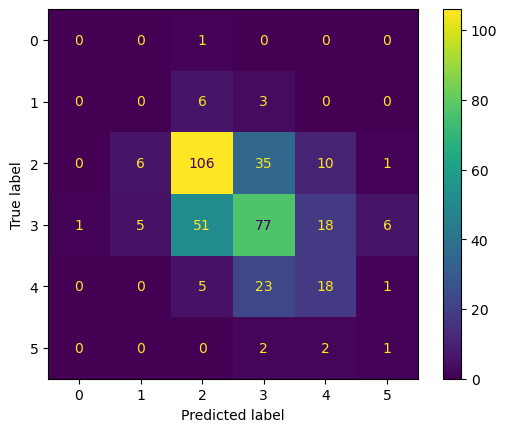

In [19]:
ConfusionMatrixDisplay.from_estimator(model_s, X_test, y_test)

In [20]:
y_pred = model_s.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.63      0.67      0.65       158
           3       0.55      0.49      0.52       158
           4       0.38      0.38      0.38        47
           5       0.11      0.20      0.14         5

    accuracy                           0.53       378
   macro avg       0.28      0.29      0.28       378
weighted avg       0.54      0.53      0.54       378



# Регрессия

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
df = fetch_california_housing(as_frame=True)
df = df.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Обучение модели

In [5]:
from tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [6]:
X = df.drop(["MedHouseVal"], axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

## Оценка модели

In [8]:
from sklearn.tree import DecisionTreeRegressor as DTR

In [12]:
model_dtr = DTR(max_depth=10)
model_dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10)

In [11]:
y_pred = model.predict(X_test)
R2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
print(R2, MAE, RMSE)

0.687906756827424 0.4423981615271451 0.6395074572682198


In [13]:
y_pred = model_dtr.predict(X_test)
R2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
print(R2, MAE, RMSE)

0.6755632923558405 0.4355863115202718 0.6520312680905913
